saved outputs/run_29433679/history.png


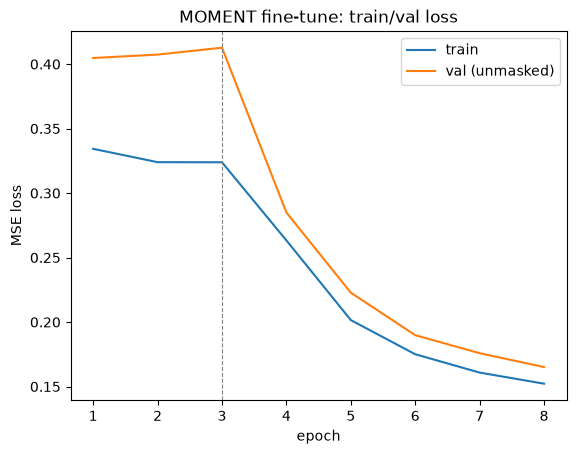

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from plot_history import load_history, plot

csv_path = Path("outputs/run_29433679/history.csv")
plot(load_history(csv_path), csv_path.with_suffix(".png"))
plt.show()



In [5]:
# setup

import pandas as pd
import matplotlib.pyplot as plt

CHANNELS = ["accel_x_A", "accel_y_A"]

def plot_comparison(csv_path, title, subset):
    df = pd.read_csv(csv_path)
    if subset is not None:
        df = df.iloc[subset[0]:subset[1]]

    fig, axes = plt.subplots(len(CHANNELS), 1, figsize=(24, 4 * len(CHANNELS)), sharex=True)
    for ax, ch in zip(axes, CHANNELS):
        ax.plot(df["sample_idx"], df[f"actual_{ch}"], label="actual", color="black", linewidth=0.8)
        ax.plot(df["sample_idx"], df[f"raw_{ch}"], label="raw MOMENT", alpha=0.7)
        ax.plot(df["sample_idx"], df[f"finetuned_{ch}"], label="fine-tuned", alpha=0.7)
        ax.set_title(f"{ch} — {title}")
        ax.set_ylabel("accel")
        ax.legend()
    axes[-1].set_xlabel("sample index")
    plt.tight_layout()
    plt.show()
    return df

def plot_error(df, title):
    fig, axes = plt.subplots(len(CHANNELS), 1, figsize=(14, 4 * len(CHANNELS)), sharex=True)
    for ax, ch in zip(axes, CHANNELS):
        err_raw = (df[f"raw_{ch}"] - df[f"actual_{ch}"]).abs()
        err_ft  = (df[f"finetuned_{ch}"] - df[f"actual_{ch}"]).abs()
        ax.plot(df["sample_idx"], err_raw, label="raw MOMENT", alpha=0.7)
        ax.plot(df["sample_idx"], err_ft, label="fine-tuned", alpha=0.7)
        ax.set_title(f"{ch} absolute error — {title}")
        ax.set_ylabel("abs error")
        ax.legend()
    axes[-1].set_xlabel("sample index")
    plt.tight_layout()
    plt.show()

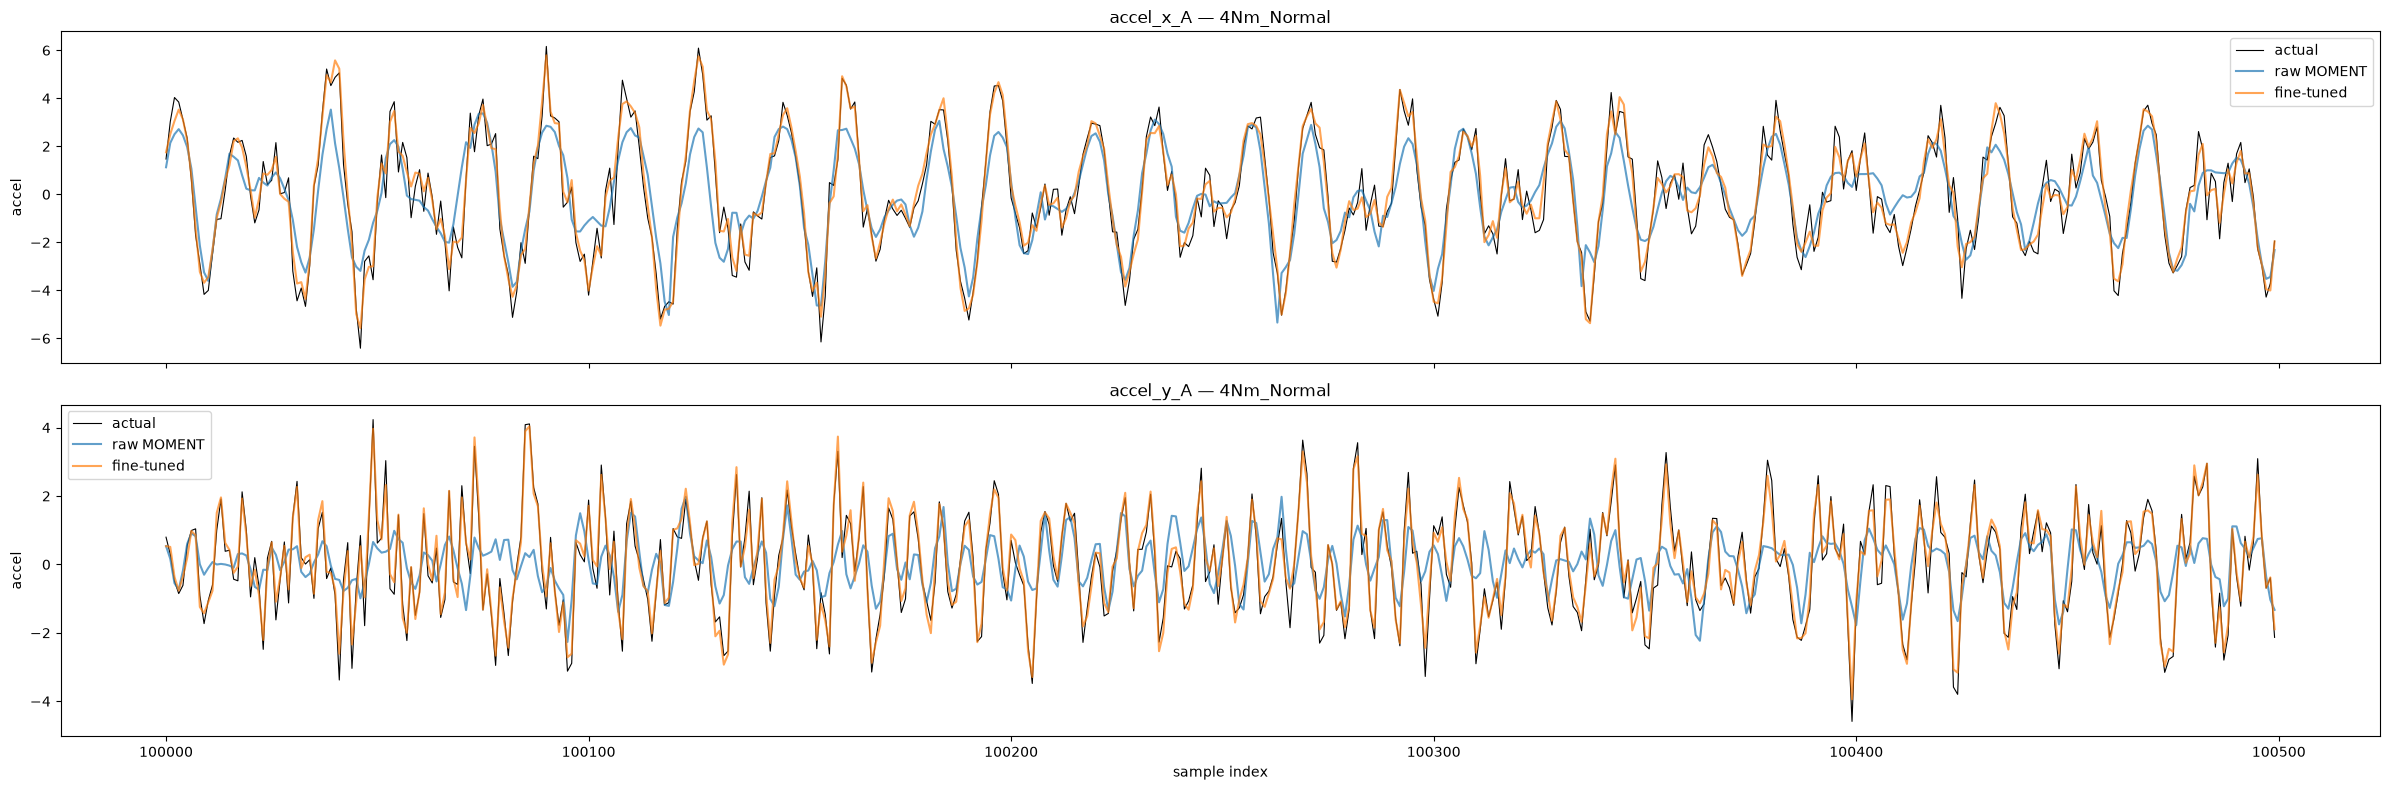

In [6]:
df_normal = plot_comparison("outputs/comparison/4Nm_Normal_reconstruction.csv", "4Nm_Normal", subset=(100000,100500))

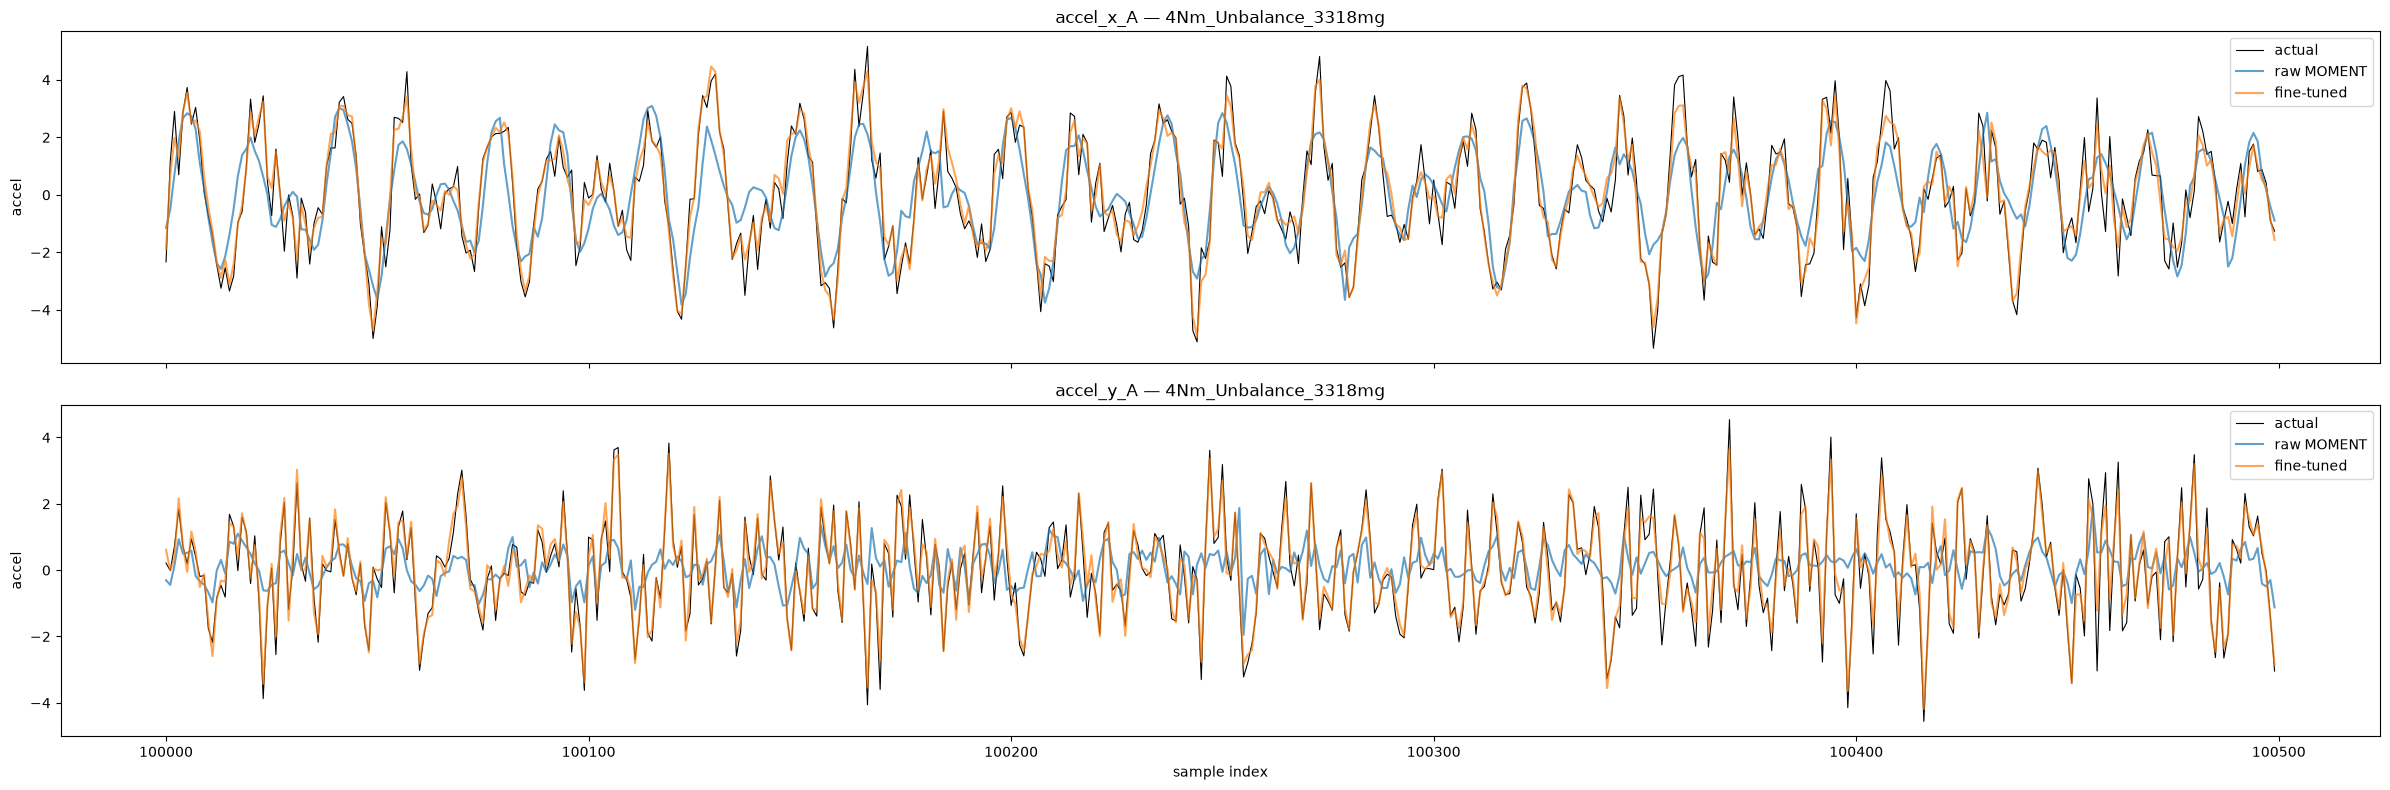

accel_x_A:  raw MSE=1.426343   fine-tuned MSE=0.211383
accel_y_A:  raw MSE=1.752773   fine-tuned MSE=0.116565


In [7]:
df_unbalance = plot_comparison(
    "outputs/comparison/4Nm_Unbalance_3318mg_reconstruction.csv", "4Nm_Unbalance_3318mg"
    , subset=(100000,100500)
)

for ch in CHANNELS:
    mse_raw = ((df_unbalance[f"raw_{ch}"] - df_unbalance[f"actual_{ch}"]) ** 2).mean()
    mse_ft  = ((df_unbalance[f"finetuned_{ch}"] - df_unbalance[f"actual_{ch}"]) ** 2).mean()
    print(f"{ch}:  raw MSE={mse_raw:.6f}   fine-tuned MSE={mse_ft:.6f}")

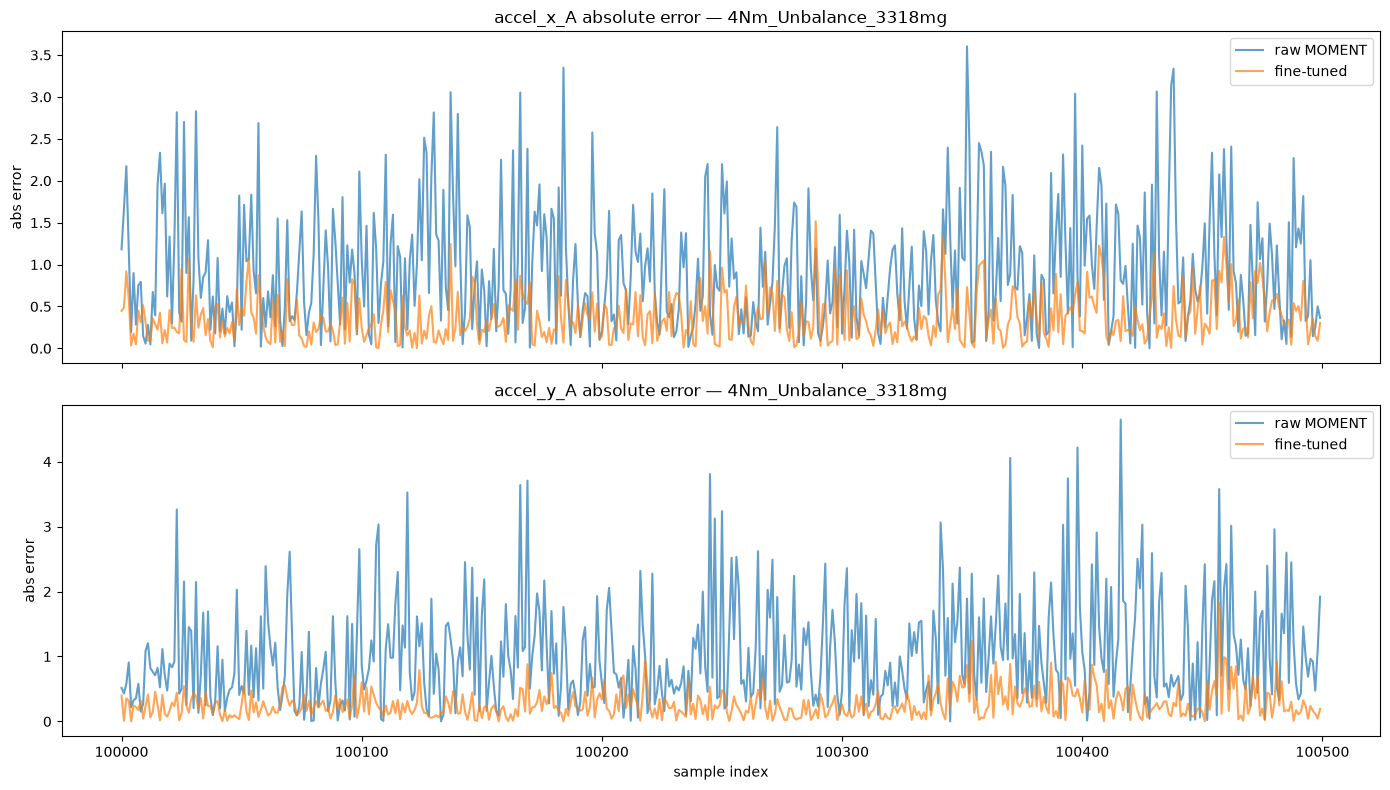

In [8]:
plot_error(df_unbalance, "4Nm_Unbalance_3318mg")